# Tau peptide detection profile (smoothed)

In [5]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

In [12]:
processed_data_path = '../data/processed_data/'
figure_path = '../figures/figure1'

## Sequence helpers

In [2]:
# 2N4R Tau sequence (441 amino acids)
TAU_2N4R = """MAEPRQEFEVMEDHAGTYGLGDRKDQGGYTMHQDQEGDTDAGLKESPLQTPTEDGSEEPG
SETSDAKSTPTAEDVTAPLVDEGAPGKQAAAQPHTEIPEGTTAEEAGIGDTPSLEDEAAG
HVTQARMVSKSKDGTGSDDKKAKGADGKTKIATPRGAAPPGQKGQANATRIPAKTPPAPK
TPPSSGEPPKSGDRSGYSSPGSPGTPGSRSRTPSLPTPPTREPKKVAVVRTPPKSPSSAK
SRLQTAPVPMPDLKNVKSKIGSTENLKHQPGGGKVQIINKKLDLSNVQSKCGSKDNIKHV
PGGGSVQIVYKPVDLSKVTSKCGSLGNIHHKPGGGQVEVKSEKLDFKDRVQSKIGSLDNI
THVPGGGNKKIETHKLTFRENAKAKTDHGAEIVYKSPVVSGDTSPRHLSNVSSTGSIDMV
DSPQLATLADEVSASLAKQGL""".replace("\n", "").replace(" ", "")


def clean_peptide_sequence(peptide_name):
    seq = re.sub(r"\d+$", "", peptide_name)
    seq = re.sub(r"\([^)]+\)", "", seq)
    return seq


def find_peptide_position(peptide_seq, protein_seq):
    pos = protein_seq.find(peptide_seq)
    if pos >= 0:
        return pos + 1
    return None

## Load CSV and build peptide table

In [8]:
df = pd.read_csv(os.path.join(processed_data_path, 'profile-plot-data.csv'))
negative_df = df[df["idx"] == "negative"].drop(columns=["idx"])
positive_df = df[df["idx"] == "positive"].drop(columns=["idx"])

peptide_columns = negative_df.columns.tolist()
peptide_info = []
for col in peptide_columns:
    clean_seq = clean_peptide_sequence(col)
    position = find_peptide_position(clean_seq, TAU_2N4R)
    neg_rate = negative_df[col].notna().sum() / len(negative_df) * 100
    pos_rate = positive_df[col].notna().sum() / len(positive_df) * 100
    peptide_info.append(
        {
            "column": col,
            "clean_sequence": clean_seq,
            "position": position,
            "neg_detection_rate": neg_rate,
            "pos_detection_rate": pos_rate,
        }
    )

peptide_df = pd.DataFrame(peptide_info)
peptide_df = peptide_df.dropna(subset=["position"])
peptide_df["position"] = peptide_df["position"].astype(int)
peptide_df = peptide_df.sort_values("position")
peptide_df.head()

,column,clean_sequence,position,neg_detection_rate,pos_detection_rate
0,QEFEVMEDHAGTYGLGDRK3,QEFEVMEDHAGTYGLGDRK,6,25.0,50.0
1,QEFEVM(UniMod:35)EDHAGTYGLGDRK3,QEFEVMEDHAGTYGLGDRK,6,15.0,60.0
2,QEFEVMEDHAGTYGLGDRK4,QEFEVMEDHAGTYGLGDRK,6,20.0,60.0
3,QEFEVMEDHAGTYGLGDR3,QEFEVMEDHAGTYGLGDR,6,35.0,80.0
4,STPTAEDVTAPLVDEGAPGK2,STPTAEDVTAPLVDEGAPGK,68,10.0,75.0


## Aggregate by position

In [9]:
neg_grouped = peptide_df.groupby("position")["neg_detection_rate"].agg(["mean", list, "count"])
neg_grouped.columns = ["mean", "values", "count"]
pos_grouped = peptide_df.groupby("position")["pos_detection_rate"].agg(["mean", list, "count"])
pos_grouped.columns = ["mean", "values", "count"]

positions = neg_grouped.index.values
neg_means = neg_grouped["mean"].values
pos_means = pos_grouped["mean"].values

## Domain map and series colors

In [16]:
domains = [
    (1, 150, "N-term", "#a6cee3"),
    (151, 243, "Proline-rich", "#b2df8a"),
    (244, 368, "MTBR", "#fb9a99"),
    (369, 441, "C-term", "#cab2d6"),
]
neg_color = "#0C6F9F"
pos_color = "#FEC200"
neg_color_light = "#F5B7B1"
pos_color_light = "#AED6F1"

## Smoothing

`smooth_factor` controls Gaussian smoothing (sigma). Dense evaluation uses 300 points between min and max position.

In [10]:
def smooth_profile(positions, values, smooth_factor=2, n_points=300):
    x_smooth = np.linspace(positions.min(), positions.max(), n_points)
    f = interp1d(positions, values, kind="linear", fill_value="extrapolate")
    y_interp = f(x_smooth)
    y_smooth = gaussian_filter1d(y_interp, sigma=smooth_factor)
    return x_smooth, y_smooth

## Figure

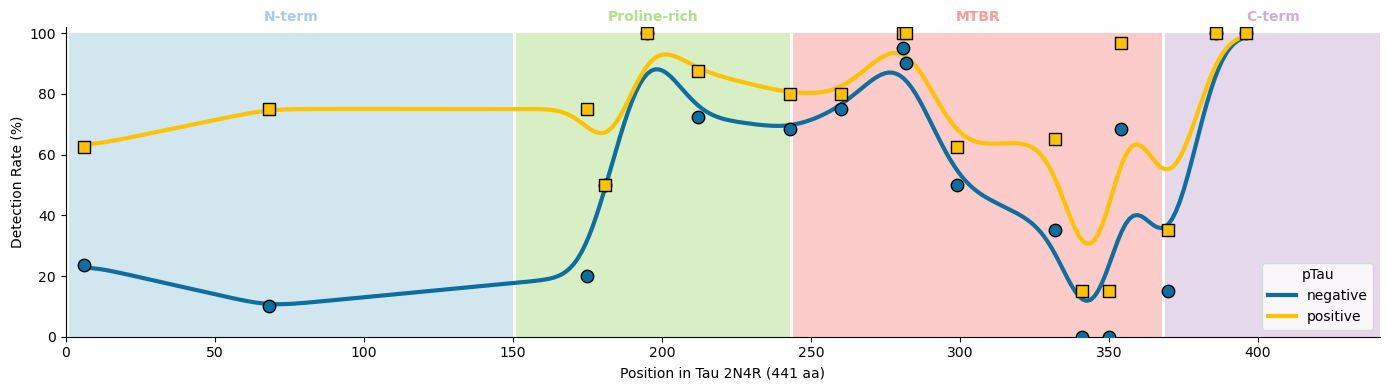

In [ ]:

FIG1_SIZE = (14, 4)
SMOOTH_FACTOR = 5
DOMAIN_RECT_TOP = 100
DOMAIN_LABEL_Y = 103
Y_LIM = (0, 102)
X_LIM = (0, 441)

fig, ax = plt.subplots(figsize=FIG1_SIZE)

for start, end, name, bg_color in domains:
    rect = Rectangle(
        (start, 0),
        end - start,
        DOMAIN_RECT_TOP,
        facecolor=bg_color,
        alpha=0.5,
        zorder=1,
    )
    ax.add_patch(rect)
    ax.text(
        (start + end) / 2,
        DOMAIN_LABEL_Y,
        name,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=bg_color,
    )

x_smooth_neg, y_smooth_neg = smooth_profile(positions, neg_means, smooth_factor=SMOOTH_FACTOR)
x_smooth_pos, y_smooth_pos = smooth_profile(positions, pos_means, smooth_factor=SMOOTH_FACTOR)
y_smooth_neg = np.clip(y_smooth_neg, 0, 100)
y_smooth_pos = np.clip(y_smooth_pos, 0, 100)

ax.plot(x_smooth_neg, y_smooth_neg, color=neg_color, linewidth=3, alpha=1, zorder=5, label="negative")
ax.plot(x_smooth_pos, y_smooth_pos, color=pos_color, linewidth=3, alpha=1, zorder=5, label="positive")

ax.scatter(
    positions,
    neg_means,
    c=neg_color,
    s=80,
    zorder=6,
    edgecolors="k",
    linewidths=1,
    marker="o", 
)
ax.scatter(
    positions,
    pos_means,
    c=pos_color,
    s=80,
    zorder=6,
    edgecolors="k",
    linewidths=1,
    marker="s", 
)

ax.set_xlabel("Position in Tau 2N4R (441 aa)")
ax.set_ylabel("Detection Rate (%)")

ax.set_ylim(*Y_LIM)
ax.set_xlim(*X_LIM)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(title="pTau", loc="lower right", fontsize=10, edgecolor="lightgray")
plt.tight_layout()

fig.savefig(os.path.join(figure_path, 'Fig1a_tau_profile_smoothed.png'), dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(os.path.join(figure_path, 'Fig1a_tau_profile_smoothed.pdf'), bbox_inches="tight", facecolor="white")

plt.show()